In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows

# Zadanie

Dysponujesz danymi z portalu Our World in Data dotyczącymi:
- Pierwotnej konsumpcji energii
- Emisji CO2 z poszczególnych lat dla różnych krajów

## Część 1: Plik CSV
Utwórz plik CSV zawierający połączone dane dla Polski:
- konsumpcja energii pierwotnej
- emisja CO2
- dane z poszczególnych lat

## Część 2: Plik Excel
Stwórz plik Excel z osobnymi zakładkami dla każdego kraju:
- UE
- USA
- Chiny
- Indie

Każda zakładka powinna zawierać dane o konsumpcji energii i emisji CO2.

## Część 3: Baza danych SQLite
Utwórz bazę danych SQLite z tabelą zawierającą:
- kraj
- rok
- emisja CO2
- konsumpcja energii

Dane powinny obejmować: Polskę, Niemcy i Hiszpanię.

## Część 4: Analiza i wizualizacja
Na podstawie danych z pliku Excel i bazy SQLite utwórz wykresy:
- emisja CO2 w zależności od roku (dla wybranego kraju)
- konsumpcja energii pierwotnej w zależności od roku (dla wybranego kraju)
- **dla chęnych szukanie koreacji**

In [5]:
df_co2 = pd.read_csv("/content/co2-emissions-per-capita.csv")
df_co2.head()

,Entity,Year,Annual CO₂ emissions (per capita)
0,Afghanistan,1949,0.001992
1,Afghanistan,1950,0.010837
2,Afghanistan,1951,0.011625
3,Afghanistan,1952,0.011468
4,Afghanistan,1953,0.013123


In [6]:
df_primary_energy = pd.read_csv("/content/primary-energy-cons.csv")
df_primary_energy.head()

,Entity,Code,Year,Primary energy consumption (TWh)
0,Afghanistan,AFG,1980,6.337187
1,Afghanistan,AFG,1981,7.289555
2,Afghanistan,AFG,1982,7.889244
3,Afghanistan,AFG,1983,9.882159
4,Afghanistan,AFG,1984,9.929878


//----------------- 1 -----------------//

In [7]:
primary_energy_pl = df_primary_energy[df_primary_energy["Entity"] == "Poland"]
primary_energy_pl.head()

,Entity,Code,Year,Primary energy consumption (TWh)
9734,Poland,POL,1965,776.05330
9735,Poland,POL,1966,791.17820
9736,Poland,POL,1967,814.29987
9737,Poland,POL,1968,876.36676
9738,Poland,POL,1969,936.06604


In [13]:
co2_pl = df_co2[df_co2["Entity"] == "Poland"]
co2_pl = co2_pl[["Year","Annual CO₂ emissions (per capita)"]]
co2_pl.head()

,Year,Annual CO₂ emissions (per capita)
19063,1800,0.045189
19064,1801,0.048900
19065,1802,0.049344
19066,1803,0.050177
19067,1804,0.049414


In [14]:
df_pl = pd.merge(primary_energy_pl, co2_pl, on="Year")
df_pl = df_pl.rename(columns={
    "Annual CO₂ emissions (per capita)": "CO2",
    "Primary energy consumption (TWh)": "Energy cons"
    })
df_pl.head()

,Entity,Code,Year,Energy cons,CO2
0,Poland,POL,1965,776.05330,7.893703
1,Poland,POL,1966,791.17820,7.996349
2,Poland,POL,1967,814.29987,8.138128
3,Poland,POL,1968,876.36676,8.597721
4,Poland,POL,1969,936.06604,9.076116


In [15]:
df_pl.to_csv("pl.csv")

//----------------- 1 -----------------//

//----------------- 2 -----------------//

In [8]:
def co2_energy_merge(df_co2, df_energy, country):
  df_energy = df_energy[df_energy["Entity"] == country]
  df_co2 = df_co2[df_co2["Entity"] == country]
  df_co2 = df_co2[["Year","Annual CO₂ emissions (per capita)"]]
  df_merge = pd.merge(df_energy, df_co2, on="Year")
  df_merge = df_merge.rename(columns={
    "Annual CO₂ emissions (per capita)": "CO2",
    "Primary energy consumption (TWh)": "Energy cons"
    })
  return df_merge

df_UE = co2_energy_merge(df_co2, df_primary_energy, "European Union (27)")
df_USA = co2_energy_merge(df_co2, df_primary_energy, "United States")
df_China = co2_energy_merge(df_co2, df_primary_energy, "China")
df_India = co2_energy_merge(df_co2, df_primary_energy, "India")

In [9]:
wb = openpyxl.Workbook()

arkusz1 = wb.active
arkusz1.title = "UE"
for row in dataframe_to_rows(df_UE, index=False, header=True):
    arkusz1.append(row)

arkusz2 = wb.create_sheet("USA")
for row in dataframe_to_rows(df_USA, index=False, header=True):
    arkusz2.append(row)

arkusz3 = wb.create_sheet("China")
for row in dataframe_to_rows(df_China, index=False, header=True):
    arkusz3.append(row)

arkusz4 = wb.create_sheet("India")
for row in dataframe_to_rows(df_India, index=False, header=True):
    arkusz4.append(row)

wb.save("zad2.xlsx")

//----------------- 2 -----------------//

//----------------- 3 -----------------//

In [10]:
conn = sqlite3.connect('zad3.sqlite')
query = """
   CREATE TABLE co2_energy (
    Entity VARCHAR(30),
    Year VARCHAR(4),
    Energy_cons FLOAT,
    CO2_emiss FLOAT
    );"""
conn.execute(query)
conn.commit()

In [16]:
df_pl = df_pl[["Entity","Year","Energy cons","CO2"]]

df_de = co2_energy_merge(df_co2, df_primary_energy, "Germany")
df_de = df_de[["Entity","Year","Energy cons","CO2"]]

df_es = co2_energy_merge(df_co2, df_primary_energy, "Spain")
df_es = df_es[["Entity","Year","Energy cons","CO2"]]

In [17]:
stmt = "INSERT INTO co2_energy VALUES(?, ?, ?, ?)"

conn.executemany(stmt, df_pl.values.tolist())
conn.executemany(stmt, df_de.values.tolist())
conn.executemany(stmt, df_es.values.tolist())
conn.commit()

In [18]:
df_db = pd.read_sql_query("SELECT * FROM co2_energy;", conn)
df_db.head()

,Entity,Year,Energy_cons,CO2_emiss
0,Poland,1965,776.05330,7.893703
1,Poland,1966,791.17820,7.996349
2,Poland,1967,814.29987,8.138128
3,Poland,1968,876.36676,8.597721
4,Poland,1969,936.06604,9.076116


//----------------- 3 -----------------//

//----------------- 4 -----------------//<br>


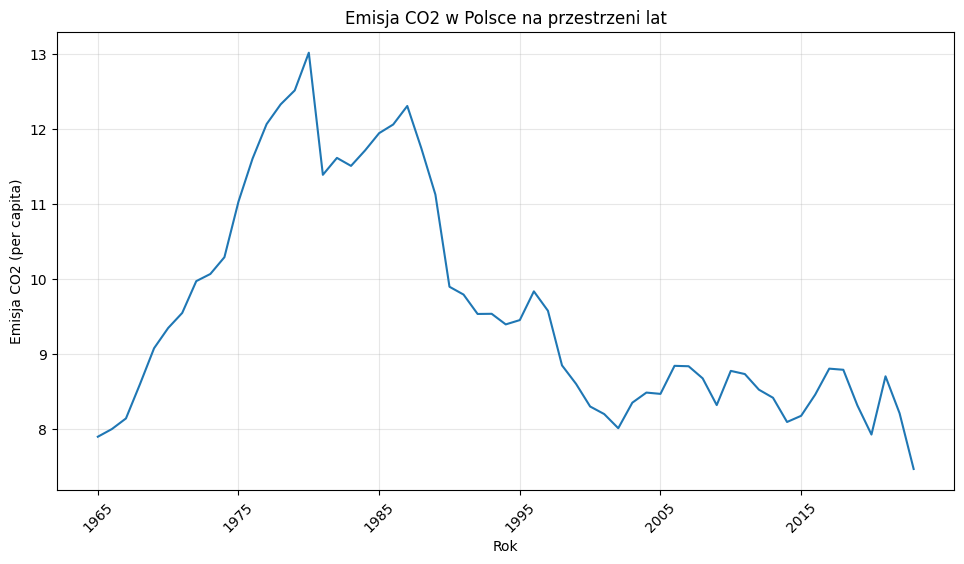

In [28]:
df_pl_readed = pd.read_sql_query("SELECT * FROM co2_energy WHERE Entity='Poland';", conn)
df_pl_readed["Year"] = pd.to_numeric(df_pl_readed["Year"], errors="coerce")

plt.figure(figsize=(10,6))
plt.plot(df_pl_readed["Year"], df_pl_readed["CO2_emiss"])
plt.xlabel("Rok")
plt.ylabel("Emisja CO2 (per capita)")
plt.title("Emisja CO2 w Polsce na przestrzeni lat")
plt.grid(True, alpha=0.3)
years = sorted(pd.to_numeric(df_pl_readed["Year"], errors="coerce").dropna().unique())
plt.xticks(years[::10], rotation=45)
plt.tight_layout(pad=2.0)
plt.show()

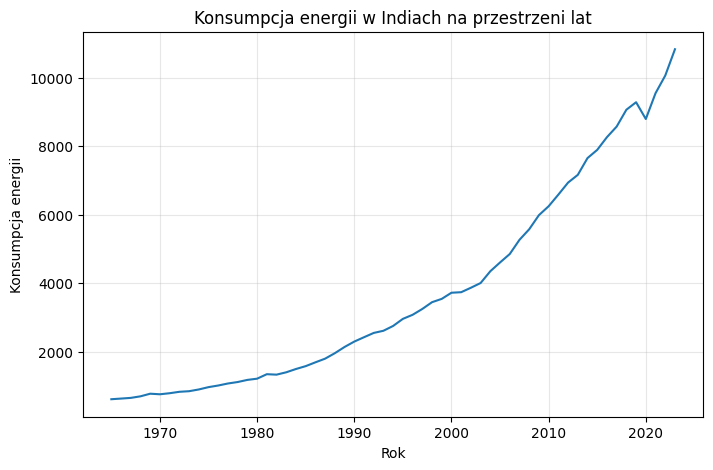

In [29]:
df_india_readed = pd.read_excel("zad2.xlsx", sheet_name="India")

plt.figure(figsize=(8,5))
plt.plot(df_india_readed["Year"], df_india_readed["Energy cons"])
plt.xlabel("Rok")
plt.ylabel("Konsumpcja energii")
plt.title("Konsumpcja energii w Indiach na przestrzeni lat")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
corr = df_pl_readed["CO2_emiss"].corr(df_pl_readed["Energy_cons"])
print("Korelacja (Polska):", corr)

corr = df_india_readed["CO2"].corr(df_india_readed["Energy cons"])
print("Korelacja (Indie):", corr)

Korelacja (Polska): 0.8226420103731802
Korelacja (Indie): 0.9984140006088775
